### Jeremy Marino

### DS4420

### Final Project 

### College Baseball Seasonal Pitching/Hitting Analysis - Time Series

## Time Series Model Goals

### Steps to implement
- Load and clean the data
- Choose batting and pitching metrics
- Standardize the stats if needed
- Encode teams, conferences, and seasons
- Fit Time Series model
- Understand relation between pitching and batting. Predict furture relationships

## Hypothesis

The reason I believe this project to be so interest is because of the relationships between the different divisions of play. I am of the opinion that the trends may differ by division because of disparity of talent between levels. Because of this, I believe the higher the division, the closer the teams and conferences will follow professional in terms of pitching and battling (i.e. higher strikeout rates and higher home run/SLG rates).

## Load/Clean Data

In [243]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import AutoReg
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [6]:
div1_df = pd.read_json(r'C:\Users\Jerem\Documents\NU SPRING 2026\DS4420\FINAL PROJECT\DS4420-BiggsMarino-Final-Project\Data\div1\2012.json').T
div1_df.shape

(292, 46)

In [8]:
div1_df.head(10)

,team,league,W,L,T,WPCT,G,BB (Batting),AB,H,...,SLG,SBPG,SO,BB (Pitching),K/BB,K/9,3B,3BPG,WHIP,BBPG (Pitching)
Utah Valley (GWC),Utah Valley,GWC,47,12,0,0.797,59,271,2031,711,...,0.523,0.92,347,169,2.05,6.3,30,0.51,1.47,3.08
Stony Brook (America East),Stony Brook,America East,52,15,0,0.776,67,243,2245,743,...,0.478,1.37,394,176,2.24,6.2,36,0.54,1.18,2.78
Purdue (Big Ten),Purdue,Big Ten,45,14,0,0.763,59,187,2107,665,...,0.431,1.03,364,128,2.84,6.2,17,0.29,1.21,2.18
UCLA (Pac-12),UCLA,Pac-12,48,16,0,0.75,64,228,2135,650,...,0.393,0.94,436,238,1.83,6.9,16,0.25,1.3,3.76
Florida St. (ACC),Florida St.,ACC,50,17,0,0.746,67,386,2230,627,...,0.414,0.94,498,228,2.18,7.5,10,0.15,1.33,3.43
Baylor (Big 12),Baylor,Big 12,49,17,0,0.742,66,296,2183,675,...,0.442,1.45,448,185,2.42,6.9,17,0.26,1.2,2.86
North Carolina (ACC),North Carolina,ACC,46,16,0,0.742,62,304,2127,587,...,0.384,1.15,530,205,2.59,8.5,25,0.4,1.25,3.27
Arizona (Pac-12),Arizona,Pac-12,48,17,0,0.738,65,234,2296,756,...,0.447,1.31,443,168,2.64,6.8,35,0.54,1.27,2.58
Army West Point (Patriot),Army West Point,Patriot,41,15,0,0.732,56,197,1748,502,...,0.362,1.95,346,148,2.34,6.6,7,0.13,1.2,2.81
UCF (CUSA),UCF,CUSA,45,17,0,0.726,62,277,2128,617,...,0.418,1.45,484,238,2.03,7.7,12,0.19,1.4,3.79


Mateo has pretty well structured data here for all 3 levels of college baseball, most of the wrangling will involve aggragting seasonal data into groups by conference, division, etc.

## Batting/Pitching Metrics

These are our initial metrics we will pass in as features for our model. They are not necessarily the best and our subject to change, however they provide a good baseline for our model.

Here is the documentation for features in this dataset: https://collegebaseballstatspackage.readthedocs.io/en/latest/season_stats.html 

### Batting Metrics

- BA (Batting Average)
- OBP (On-Base Percentage)
- SLG (Slugging Percentage)
- HRPG (Home-Run Percentage)
- RPG (Runs Per Game)

### Pitching Metrics

- ERA (Earned Run Average)
- WHIP (Walks and Hits Per Inning Pitched)
- K/9 (Strikeouts Per 9 Innings Pitched)
- K/BB (Strikeouts / Walk Ratio)

In [227]:
# consts

DIV_1_CONFERENCES = [
    'America_East', 'Big_Ten', 'Pac-12', 'ACC', 'Big_12',
    'Patriot', 'CUSA', 'SEC', 'WCC', 'MAC', 'MEAC', 'Big_South',
    'Atlantic_10', 'SoCon', 'MVC', 'SWAC', 'Summit_League',
    'The_American', 'Southland', 'Mountain_West', 'ASUN', 'Big_West',
    'Ivy_League', 'Horizon', 'CAA', 'OVC', 'Sun_Belt', 'NEC', 'WAC',
    'MAAC'
]

DIV_2_CONFERENCES = [
    'CACC', 'CCAA', 'Conference_Carolinas', 'East_Coast',
    'GAC', 'GLIAC', 'GLVC', 'GNAC', 'Great_Midwest',
    'Gulf_South', 'Heartland', 'Lone_Star', 'MIAA',
    'Mountain_East', 'NE-10', 'Northern_Sun', 'Peach_Belt',
    'PSAC', 'RMAC', 'South_Atlantic', 'SIAC',
    'Sunshine_State'
]

DIV_3_CONFERENCES = [
    'Allegheny_Mountain', 'American_Rivers', 'American_Southwest',
    'Atlantic_East', 'Centennial', 'Coast_to_Coast', 'CCIW',
    'Colonial_States', 'Commonwealth_Coast', 'Collegiate_South',
    'CUNY', 'Empire_8', 'Great_Northeast', 'Heartland_Collegiate',
    'Landmark', 'Liberty_League', 'Little_East', 'MASCAC',
    'Michigan_Intercollegiate', 'Middle_Atlantic', 'Midwest',
    'MIAC', 'NECC', 'NESCAC', 'NEWMAC',
    'NJAC', 'North_Atlantic', 'NACC', 'North_Coast',
    'Northwest', 'OAC', 'ODAC', 'Presidents',
    'SAA', 'SCIAC', 'Skyline', 'SLIAC',
    'SUNYAC', 'United_East', 'UAA', 'Upper_Midwest',
    'USA_South', 'WIAC'
]

BAT_METRICS = [
    'BA',
    'OBP',
    'SLG',
    'HRPG',
    'RPG',
]

PITCH_METRICS = [
    'ERA',
    'WHIP',
    'K/9',
    'K/BB'
]

In [12]:
# returns dict with historic conference data
def get_historic_conference_data(div=1):
    conf_dict = {}
    # data is from 2012-2025
    for year in range(2012, 2026):
        path = f'C:/Users/Jerem/Documents/NU SPRING 2026/DS4420/FINAL PROJECT/DS4420-BiggsMarino-Final-Project/Data/div{div}/{year}.json'
        df = pd.read_json(path).T
        year_confs = [conf.replace(' ', '_') for conf in df['league'].unique()[:-1]] 
        for conf, conf_ in zip(df['league'].unique()[:-1], year_confs):
            conf_dict[f'{conf_}_{year}'] = {
                'BA': round(float(df[df['league'] == conf]['BA'].mean()), 3),
                'OBP': round(float(df[df['league'] == conf]['OBP'].mean()), 3),
                'SLG': round(float(df[df['league'] == conf]['SLG'].mean()), 3),
                'HRPG': round(float(df[df['league'] == conf]['HRPG'].mean()), 3),
                'RPG': round(float(df[df['league'] == conf]['RPG'].mean()), 3),
                'ERA': round(float(df[df['league'] == conf]['ERA'].mean()), 3),
                'WHIP': round(float(df[df['league'] == conf]['WHIP'].mean()), 3),
                'K/9': round(float(df[df['league'] == conf]['K/9'].mean()), 3),
                'K/BB': round(float(df[df['league'] == conf]['K/BB'].mean()), 3)
            }
    return conf_dict

In [213]:
# filter to only conferences present in all 14 seasons
def get_full_conferences(conf_dict):
    years = list(range(2012, 2026))
    return [
        conf for conf in DIV_1_CONFERENCES
        if all(f'{conf}_{year}' in conf_dict for year in years)
    ]

# prints graph of conference's current trend, all_conf argument prints all conferences for the metric
# use conference notation above for conf_ argument 
def get_conf_trend(conf_dict, metric, conf_=None, all_conf=False, visualizations=False):
    years = list(range(2012, 2026))
    full_conferences = get_full_conferences(conf_dict)
    if visualizations:
        plt.figure(figsize=(12, 6))

    if all_conf:
        # collect all conference values per year for division average
        year_values = {year: [] for year in years}
        for conf in sorted(full_conferences):
            values = []
            valid_years = []
            for year in years:
                key = f'{conf}_{year}'
                valid_years.append(year)
                values.append(conf_dict[key][metric])
                year_values[year].append(conf_dict[key][metric])
            if visualizations:
                plt.plot(valid_years, values, marker='o', alpha=0.4, label=conf)

        # division-wide average line
        avg_years = [y for y in years if year_values[y]]
        avg_values = [np.mean(year_values[y]) for y in avg_years]
        if visualizations:
            plt.plot(avg_years, avg_values, color='black', linewidth=2.5,
                     linestyle='--', marker='s', label='Division Avg')
            plt.title(f'{metric} Average by Conference since 2012')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

        years_return = avg_years
        values_return = avg_values
    else:
        values = []
        valid_years = []
        for year in years:
            key = f'{conf_}_{year}'
            if key in conf_dict:
                valid_years.append(year)
                values.append(conf_dict[key][metric])
        if visualizations:
            plt.plot(valid_years, values, marker='o', alpha=0.6)
            plt.title(f'{metric} Average in {conf_} since 2012')

        years_return = valid_years
        values_return = values
    if visualizations:
        plt.xlabel('Year')
        plt.ylabel(f'{metric} Average')
        plt.xticks(years, rotation=45)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    return years_return, values_return

In [215]:
def get_acf_pacf(metric, title_name, metric_df):
    """
    Draw ACF and PACF graphs for metrics
    
    Parameters:
        metric:      stat that is ito be modeled (BA, OBP, etc)
        title_name:  division/conference name 
        metric_df:   DataFrame of metric (pre-filtered)
    """
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    plot_acf(metric_df['avg'], ax=ax[0], title=f'{title_name} {metric} ACF Plot')
    ax[0].grid(True, alpha=0.3)

    plot_pacf(metric_df['avg'], ax=ax[1], title=f'{title_name} {metric} PACF Plot')
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [217]:
conf_dict = get_historic_conference_data(div=1)

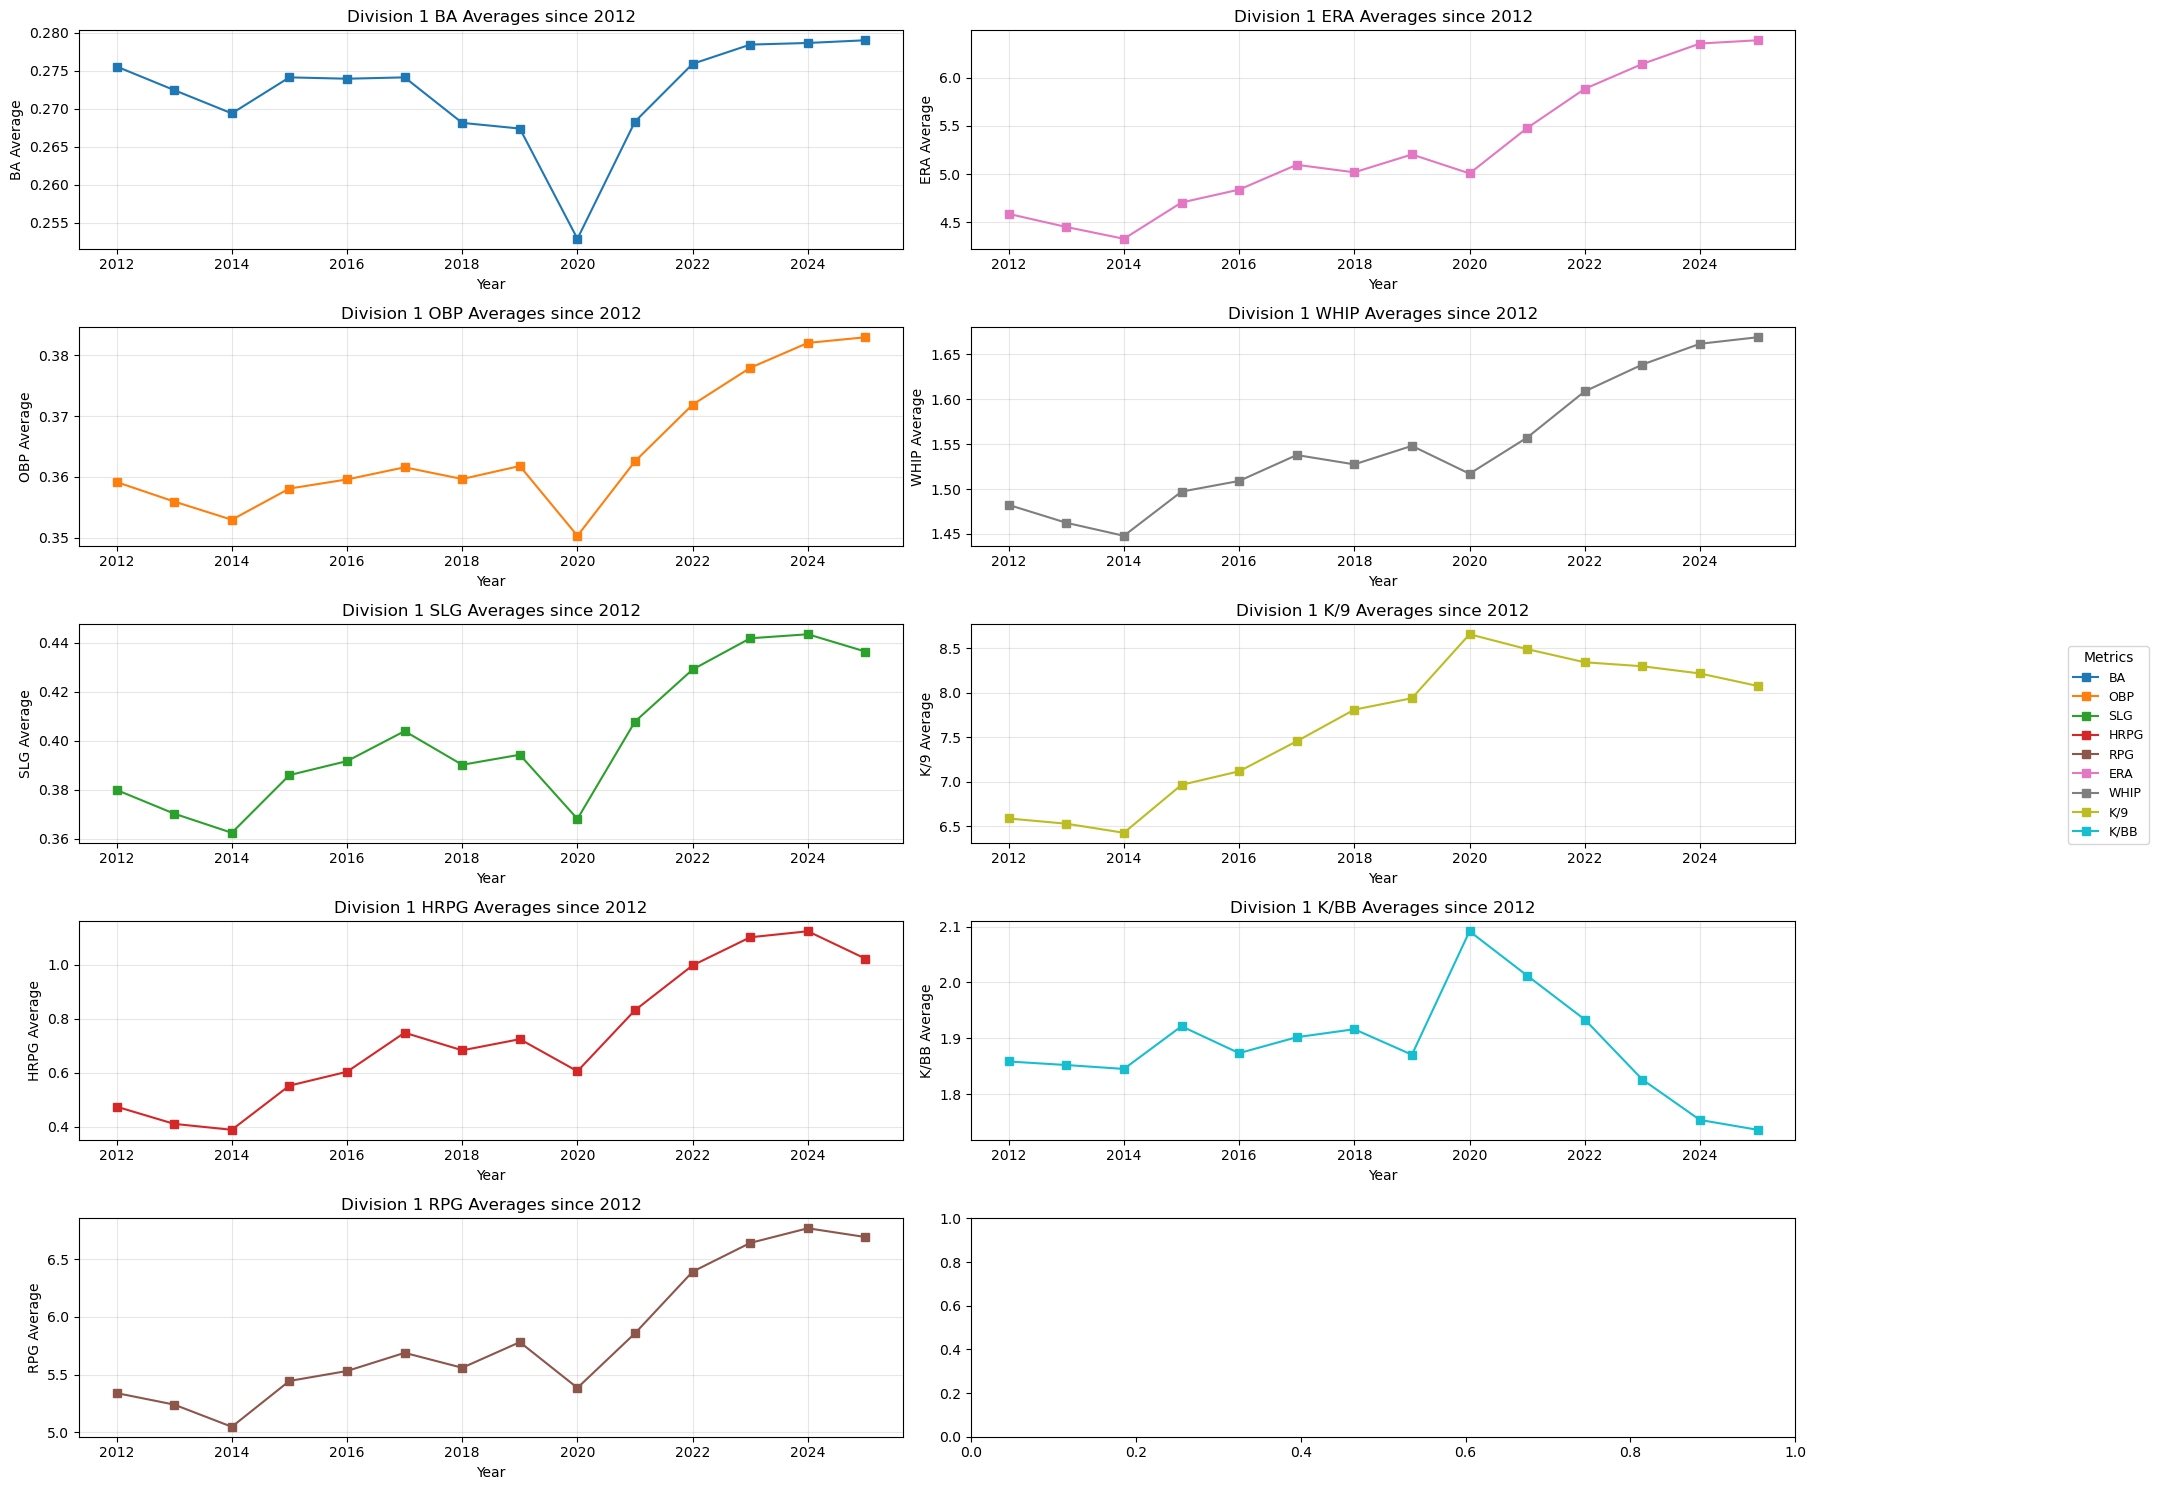

In [245]:
avg_metric_dict = {}
all_metrics = BAT_METRICS + PITCH_METRICS

# generate distinct colors for each metric
colors = cm.tab10(np.linspace(0, 1, len(all_metrics)))

fig, axes = plt.subplots(5, 2, figsize=(20, 15))
legend_handles = []

for i, metric in enumerate(all_metrics):
    years, avg = get_conf_trend(conf_dict, metric=metric, all_conf=True)
    avg_metric_dict['year'] = years
    avg_metric_dict[f'avg_{metric}'] = avg

    if i < len(BAT_METRICS):
        x = i
        y = 0
    else:
        x = i - len(BAT_METRICS)
        y = 1

    line, = axes[x, y].plot(years, avg, marker='s', color=colors[i], label=metric)
    axes[x, y].set_title(f'Division 1 {metric} Averages since 2012')
    axes[x, y].set_xlabel('Year')
    axes[x, y].set_ylabel(f'{metric} Average')
    axes[x, y].grid(True, alpha=0.3)

    legend_handles.append(line)

fig.legend(
    handles=legend_handles,
    labels=all_metrics,
    loc='center right',
    bbox_to_anchor=(1.08, 0.5),
    fontsize=9,
    title='Metrics'
)

plt.tight_layout()
plt.subplots_adjust(right=0.9)
plt.show()

avg_metric_df = pd.DataFrame(avg_metric_dict)

It's clear there is a strong correlation in average conference trends between batting and pitching metrics. WHIP and ERA seem to follow the same pattern that appears in all our batting metrics (HRPG is particularly close).

In [221]:
avg_metric_df

,year,avg_BA,avg_OBP,avg_SLG,avg_HRPG,avg_RPG,avg_ERA,avg_WHIP,avg_K/9,avg_K/BB
0,2012,0.275571,0.359143,0.379929,0.473607,5.339571,4.585250,1.482393,6.584786,1.858286
1,2013,0.272464,0.355929,0.370250,0.409893,5.239821,4.449179,1.462500,6.525964,1.851964
2,2014,0.269393,0.352929,0.362429,0.388000,5.047464,4.326179,1.448000,6.423571,1.844964
3,2015,0.274143,0.358071,0.386000,0.551607,5.444679,4.703500,1.497179,6.963679,1.921393
4,2016,0.273964,0.359571,0.391714,0.603000,5.530893,4.837679,1.509071,7.116107,1.873250
5,2017,0.274143,0.361571,0.403964,0.747750,5.688321,5.095857,1.537929,7.454536,1.901786
6,2018,0.268143,0.359643,0.390214,0.682393,5.558929,5.017607,1.527536,7.810571,1.916071
7,2019,0.267393,0.361786,0.394321,0.723786,5.781000,5.203500,1.548143,7.939607,1.870429
8,2020,0.252857,0.350286,0.368107,0.604929,5.384786,5.006179,1.517107,8.659786,2.091536
9,2021,0.268321,0.362571,0.407893,0.831321,5.857964,5.478429,1.557357,8.492143,2.012143


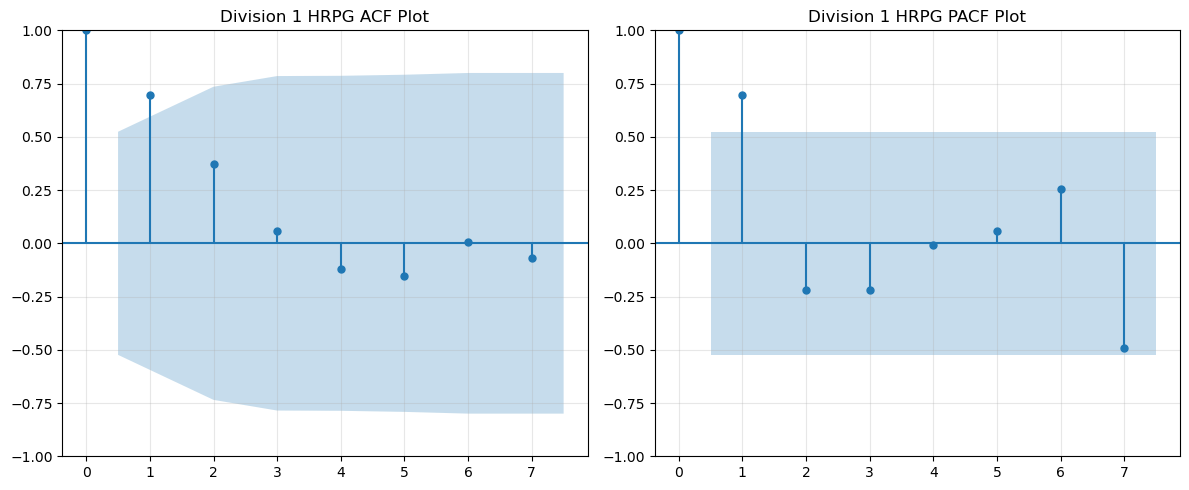

In [188]:
#years, avg
get_acf_pacf(metric='HRPG', title_name='Division 1', metric_df=OBP_avg_df)

Although the series is limited, we do see a sort of gradual descent in our ACF and a cut off around mark 2 in our PACF. Because of this, we will start our manual model using an Auto Regression with a lag of 2 and see how it fits our data.

## Manual Auto Regression

### Preprocessing

In [31]:
conference_df = pd.DataFrame(conf_dict)
conference_df

,GWC_2012,America_East_2012,Big_Ten_2012,Pac-12_2012,ACC_2012,Big_12_2012,Patriot_2012,CUSA_2012,SEC_2012,WCC_2012,...,Horizon_2025,America_East_2025,OVC_2025,NEC_2025,Summit_League_2025,SWAC_2025,WAC_2025,Mountain_West_2025,WCC_2025,Patriot_2025
BA,0.296,0.286,0.277,0.286,0.277,0.276,0.268,0.282,0.275,0.271,...,0.276,0.272,0.277,0.277,0.272,0.294,0.288,0.294,0.267,0.265
OBP,0.379,0.366,0.355,0.367,0.369,0.364,0.350,0.369,0.361,0.348,...,0.388,0.375,0.377,0.385,0.367,0.406,0.386,0.379,0.366,0.384
SLG,0.405,0.394,0.376,0.396,0.403,0.383,0.359,0.383,0.388,0.367,...,0.440,0.424,0.428,0.406,0.398,0.449,0.448,0.455,0.414,0.389
HRPG,0.429,0.403,0.463,0.507,0.613,0.479,0.310,0.488,0.578,0.406,...,1.080,0.943,1.002,0.698,0.750,0.893,1.054,0.985,0.989,0.573
RPG,6.043,5.500,5.345,5.591,5.883,5.433,4.950,5.444,5.283,4.822,...,6.950,6.229,6.650,6.337,5.900,7.417,6.833,6.700,5.989,6.150
ERA,6.079,5.633,4.081,3.775,3.845,3.780,4.578,3.953,3.589,3.682,...,7.823,6.457,6.284,8.240,6.690,8.533,6.217,6.539,6.350,6.513
WHIP,1.740,1.593,1.413,1.356,1.377,1.307,1.488,1.408,1.288,1.366,...,1.858,1.691,1.681,2.014,1.708,2.002,1.636,1.708,1.642,1.740
K/9,5.929,5.633,6.318,6.355,7.592,7.200,6.483,7.089,7.442,6.833,...,7.700,7.714,7.300,7.650,7.720,6.975,7.867,7.787,8.033,7.967
K/BB,1.534,1.637,1.972,1.993,2.084,2.397,1.705,1.946,2.567,2.069,...,1.297,1.614,1.637,1.221,1.662,1.124,1.922,1.786,1.716,1.493


In [130]:
# returns a conference's seasons
def get_conf_seasons(df, conf_='SEC_'):
    """
    Get conference DataFrame in Season by Season format
    
    Parameters:
        df:          division DataFrame (cols = ConfName_Year, rows = stats)
        conf_:       conference name (in underscore notation)
    """
    conf_cols = [col for col in df.columns if col.startswith(conf_)]
    conf_df = df[conf_cols]
    return conf_df

sec_season_stats = get_conf_seasons(conference_df, conf_='SEC_')
sec_season_stats

,SEC_2012,SEC_2013,SEC_2014,SEC_2015,SEC_2016,SEC_2017,SEC_2018,SEC_2019,SEC_2020,SEC_2021,SEC_2022,SEC_2023,SEC_2024,SEC_2025
BA,0.275,0.276,0.275,0.279,0.279,0.272,0.278,0.274,0.289,0.270,0.282,0.283,0.282,0.284
OBP,0.361,0.360,0.360,0.364,0.366,0.362,0.374,0.371,0.397,0.365,0.382,0.395,0.393,0.394
SLG,0.388,0.376,0.370,0.405,0.407,0.410,0.432,0.429,0.456,0.443,0.473,0.492,0.493,0.487
HRPG,0.578,0.499,0.450,0.701,0.709,0.854,1.032,1.046,1.150,1.277,1.457,1.609,1.664,1.531
RPG,5.283,5.300,5.257,5.643,5.936,5.750,6.293,6.479,7.543,6.393,7.050,7.407,7.314,7.294
ERA,3.589,3.410,3.258,3.770,3.817,3.987,4.149,4.158,2.859,4.494,4.621,5.159,5.039,4.796
WHIP,1.288,1.298,1.259,1.333,1.340,1.319,1.356,1.329,1.151,1.349,1.382,1.456,1.411,1.376
K/9,7.442,7.057,7.014,7.993,8.421,8.707,8.757,9.407,10.721,10.050,9.964,10.086,10.221,10.500
K/BB,2.567,2.233,2.274,2.343,2.520,2.477,2.416,2.559,3.308,2.764,2.576,2.348,2.536,2.704


In [61]:
def build_panel(df, metric, lag=1):
    """
    Reshape conference DataFrame into a long-format panel with lagged features.
    
    Returns a DataFrame like:
        year | conference | value | lag_1 | lag_2 | ...
    """
    rows = []
    for conf in DIV_1_CONFERENCES:
        cols = sorted(
            [c for c in df.columns if c.startswith(f'{conf}_')],
            key=lambda c: int(c.split('_')[-1])
        )
        years = [int(c.split('_')[-1]) for c in cols]
        values = [float(df.loc[metric, c]) for c in cols]

        for i in range(lag, len(values)):
            row = {
                'year': years[i],
                'conference': conf,
                'value': values[i]
            }
            for l in range(1, lag + 1):
                row[f'lag_{l}'] = values[i - l]
            rows.append(row)

    return pd.DataFrame(rows)

In [146]:
df_panel = build_panel(conference_df, metric='OBP', lag=1)
df_panel.head(20)

,year,conference,value,lag_1
0,2013,America_East,0.336,0.366
1,2014,America_East,0.346,0.336
2,2015,America_East,0.361,0.346
3,2016,America_East,0.362,0.361
4,2017,America_East,0.365,0.362
5,2018,America_East,0.348,0.365
6,2019,America_East,0.350,0.348
7,2020,America_East,0.321,0.350
8,2021,America_East,0.361,0.321
9,2022,America_East,0.376,0.361


This helper function creates lags for our AR model. It will allow us to easily tweak the hyper parameters of our model.

### Model Design

In [167]:
def panel_ar(df, metric, lag=1, test_years=2, forecast_years=3, visualizations=False):
    """
    Fit an AR model on the full conference panel with conference dummies.
    
    Parameters:
        df:          conference DataFrame (cols = ConfName_Year, rows = stats)
        metric:      stat to model (e.g. 'ERA')
        lag:         number of lagged seasons as features
        test_years:  number of recent seasons to hold out
    """
    # build panel
    panel = build_panel(df, metric, lag)
    cutoff = panel['year'].max() - test_years + 1

    train = panel[panel['year'] < cutoff]
    test = panel[panel['year'] >= cutoff]

    # features: lags + conference dummies
    lag_cols = [f'lag_{l}' for l in range(1, lag + 1)]
    train_dummies = pd.get_dummies(train['conference'], prefix='conf', drop_first=True)
    test_dummies = pd.get_dummies(test['conference'], prefix='conf', drop_first=True)

    # align dummy columns
    test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)

    X_train = np.column_stack([np.ones(len(train)), train[lag_cols].values, train_dummies.values])
    y_train = train['value'].values
    X_test = np.column_stack([np.ones(len(test)), test[lag_cols].values, test_dummies.values])
    y_test = test['value'].values

    # solve closed form solution
    coeffs = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)
    y_pred_train = X_train @ coeffs
    y_pred_test = X_test @ coeffs

    # metrics
    train_residuals = y_train - y_pred_train
    train_rmse = np.sqrt(np.mean(train_residuals ** 2))
    test_rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
    residual_std = np.std(train_residuals)

    # print lag coefficients
    print(f"Panel AR({lag}) for {metric}")
    print("=" * 40)
    print(f"  {'Intercept':<12} {coeffs[0]:.6f}")
    for i in range(lag):
        print(f"  {'lag_' + str(i+1):<12} {coeffs[i+1]:.6f}")
    print(f"\n  Train RMSE:  {train_rmse:.4f}")
    print(f"  Test RMSE:   {test_rmse:.4f}")
    print(f"  Residual Std: {residual_std:.4f}")
    print(f"  Train size:  {len(train)}")
    print(f"  Test size:   {len(test)}")
    print("=" * 40)

    # forcast years ahead
    yearly_avg = panel.groupby('year')['value'].mean()
    recent_values = list(yearly_avg.sort_index().values)

    # lag coefficients only (intercept + lags, no conference dummies = avg conference)
    intercept = coeffs[0]
    lag_coeffs = coeffs[1:lag + 1]
    # average conference dummy effect
    dummy_coeffs = coeffs[lag + 1:]
    avg_dummy_effect = np.mean(dummy_coeffs)

    forecast_vals = []
    forecast_stds = []
    history = list(recent_values)

    for step in range(1, forecast_years + 1):
        lags = [history[-i] for i in range(1, lag + 1)]
        y_hat = intercept + np.dot(lag_coeffs, lags) + avg_dummy_effect
        forecast_vals.append(y_hat)
        # variance grows with each step: σ * sqrt(step)
        forecast_stds.append(residual_std * np.sqrt(step))
        history.append(y_hat)

    forecast_vals = np.array(forecast_vals)
    forecast_stds = np.array(forecast_stds)
    last_year = int(panel['year'].max())
    forecast_year_labels = [last_year + i for i in range(1, forecast_years + 1)]

    # build results DataFrames averaged by year
    train_result = train[['year', 'value']].copy()
    train_result['predicted'] = y_pred_train
    train_yearly = train_result.groupby('year')[['value', 'predicted']].mean().reset_index()
    
    test_result = test[['year', 'conference', 'value']].copy()
    test_result['predicted'] = y_pred_test
    test_yearly = test_result.groupby('year')[['value', 'predicted']].mean().reset_index()

    if visualizations:
        # full timeline for context
        all_yearly = pd.concat([train_yearly, test_yearly]).sort_values('year')
    
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
        # [0,0] test set: actual vs predicted bar chart
        axes[0, 0].bar(test_yearly['year'] - 0.15, test_yearly['value'], width=0.3, label='Actual', color='steelblue')
        axes[0, 0].bar(test_yearly['year'] + 0.15, test_yearly['predicted'], width=0.3, label='Predicted', color='coral')
        axes[0, 0].set_title(f'{metric} — Test Set (Avg Across Conferences)')
        axes[0, 0].set_xlabel('Year')
        axes[0, 0].set_ylabel(metric)
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
    
        # [0,1] residuals scatter
        residuals = y_train - y_pred_train
        axes[0, 1].scatter(y_pred_train, residuals, alpha=0.5, color='steelblue')
        axes[0, 1].axhline(0, color='black', linewidth=0.8)
        axes[0, 1].set_title('Residuals vs Predicted')
        axes[0, 1].set_xlabel('Predicted')
        axes[0, 1].set_ylabel('Residual')
        axes[0, 1].grid(True, alpha=0.3)
    
        # [1,0] test period: actual vs predicted line
        axes[1, 0].plot(test_yearly['year'], test_yearly['value'], 'o-', label='Actual', color='steelblue')
        axes[1, 0].plot(test_yearly['year'], test_yearly['predicted'], 'o--', label='Predicted', color='coral')
        axes[1, 0].set_title(f'{metric} Actual vs Predicted since {int(test_yearly["year"].iloc[0])}')
        axes[1, 0].set_xlabel('Year')
        axes[1, 0].set_ylabel(metric)
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
        # [1,1] full timeline + forecast with confidence bands
        axes[1, 1].plot(all_yearly['year'], all_yearly['value'], 'o-', label='Actual', color='steelblue')
        axes[1, 1].plot(test_yearly['year'], test_yearly['predicted'], 'o--', label='Predicted (Test)', color='coral')
        axes[1, 1].plot(forecast_year_labels, forecast_vals, 's--', label='Forecast', color='green')
        axes[1, 1].fill_between(
            forecast_year_labels,
            forecast_vals - 1.96 * forecast_stds,
            forecast_vals + 1.96 * forecast_stds,
            alpha=0.2, color='green', label='95% CI'
        )
        axes[1, 1].fill_between(
            forecast_year_labels,
            forecast_vals - forecast_stds,
            forecast_vals + forecast_stds,
            alpha=0.3, color='green', label='68% CI'
        )
        axes[1, 1].axvline(cutoff - 0.5, color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')
        axes[1, 1].set_title(f'{metric} Full Timeline + Forecast')
        axes[1, 1].set_xlabel('Year')
        axes[1, 1].set_ylabel(metric)
        axes[1, 1].legend(fontsize=8)
        axes[1, 1].grid(True, alpha=0.3)
    
        plt.tight_layout()
        plt.show()

    return panel, coeffs, test_result

Panel AR(1) for OBP
  Intercept    0.372531
  lag_1        0.003145

  Train RMSE:  0.0102
  Test RMSE:   0.0230
  Residual Std: 0.0102
  Train size:  300
  Test size:   86
0.3725314285054744


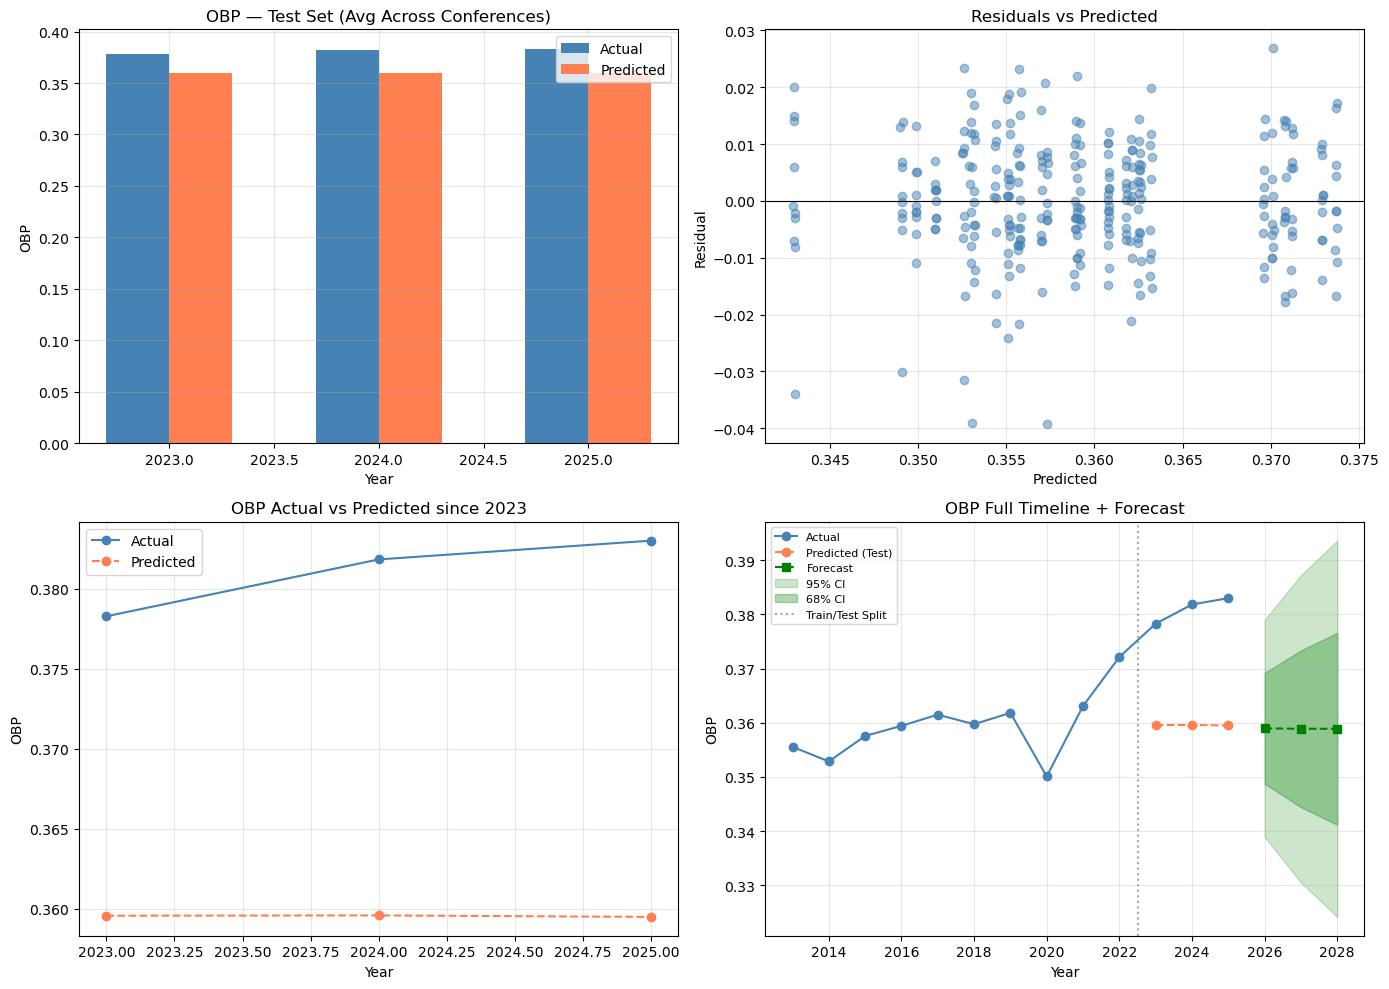

In [169]:
#panel, coeffs, results = panel_ar(conference_df, 'OBP', lag=2, test_years=2, visualizations=True)
panel, coeffs, results = panel_ar(conference_df, 'OBP', lag=1, test_years=3, visualizations=True)

#### Dr. Gerber Questions
- How to handle such small data?
- Any gaps in my domain knowledge when building this?
- Remove 2020?

In [173]:
def panel_ar(df, metric, lag=1, test_years=2, forecast_years=3, visualizations=False):
    """
    Fit an AR model on the full conference panel with conference dummies for analysis,
    and a separate division-average AR model for forecasting.
    """
    # ============================================================
    # PANEL MODEL (for analysis & test evaluation)
    # ============================================================
    panel = build_panel(df, metric, lag)
    cutoff = panel['year'].max() - test_years + 1

    train = panel[panel['year'] < cutoff]
    test = panel[panel['year'] >= cutoff]

    lag_cols = [f'lag_{l}' for l in range(1, lag + 1)]
    train_dummies = pd.get_dummies(train['conference'], prefix='conf', drop_first=True)
    test_dummies = pd.get_dummies(test['conference'], prefix='conf', drop_first=True)
    test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)

    X_train = np.column_stack([np.ones(len(train)), train[lag_cols].values, train_dummies.values])
    y_train = train['value'].values
    X_test = np.column_stack([np.ones(len(test)), test[lag_cols].values, test_dummies.values])
    y_test = test['value'].values

    coeffs = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)
    y_pred_train = X_train @ coeffs
    y_pred_test = X_test @ coeffs

    train_residuals = y_train - y_pred_train
    train_rmse = np.sqrt(np.mean(train_residuals ** 2))
    test_rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))

    # ============================================================
    # DIVISION-AVERAGE AR MODEL (for forecasting)
    # ============================================================
    yearly_avg = panel.groupby('year')['value'].mean().sort_index()
    avg_years = yearly_avg.index.values
    avg_values = yearly_avg.values

    # build lagged matrix on the division averages directly
    n = len(avg_values)
    X_avg = np.ones((n - lag, lag + 1))
    y_avg = avg_values[lag:]
    for i in range(lag):
        X_avg[:, i + 1] = avg_values[lag - i - 1 : n - i - 1]

    # split the average series the same way
    avg_cutoff_idx = np.searchsorted(avg_years[lag:], cutoff)
    X_avg_train = X_avg[:avg_cutoff_idx]
    y_avg_train = y_avg[:avg_cutoff_idx]
    X_avg_test = X_avg[avg_cutoff_idx:]
    y_avg_test = y_avg[avg_cutoff_idx:]

    # fit AR on division averages
    avg_coeffs = np.linalg.solve(X_avg_train.T @ X_avg_train, X_avg_train.T @ y_avg_train)
    avg_fitted = X_avg_train @ avg_coeffs
    avg_pred_test = X_avg_test @ avg_coeffs
    avg_residuals = y_avg_train - avg_fitted
    residual_std = np.std(avg_residuals)

    # forecast using the division-average AR model
    history = list(avg_values)
    forecast_vals = []
    forecast_stds = []

    for step in range(1, forecast_years + 1):
        lags = [history[-i] for i in range(1, lag + 1)]
        y_hat = avg_coeffs[0] + np.dot(avg_coeffs[1:], lags)
        forecast_vals.append(y_hat)
        forecast_stds.append(residual_std * np.sqrt(step))
        history.append(y_hat)

    forecast_vals = np.array(forecast_vals)
    forecast_stds = np.array(forecast_stds)
    last_year = int(avg_years[-1])
    forecast_year_labels = [last_year + i for i in range(1, forecast_years + 1)]

    # ============================================================
    # PRINT SUMMARY
    # ============================================================
    print(f"Panel AR({lag}) for {metric}")
    print("=" * 50)
    print(f"  --- Panel Model (conference-level) ---")
    print(f"  {'Intercept':<12} {coeffs[0]:.6f}")
    for i in range(lag):
        print(f"  {'lag_' + str(i+1):<12} {coeffs[i+1]:.6f}")
    print(f"  Train RMSE:  {train_rmse:.4f}")
    print(f"  Test RMSE:   {test_rmse:.4f}")
    print()
    print(f"  --- Division Avg AR (for forecasting) ---")
    print(f"  {'Intercept':<12} {avg_coeffs[0]:.6f}")
    for i in range(lag):
        print(f"  {'lag_' + str(i+1):<12} {avg_coeffs[i+1]:.6f}")
    print(f"  Residual Std: {residual_std:.4f}")
    print(f"  Forecast:     {dict(zip(forecast_year_labels, np.round(forecast_vals, 4)))}")
    print("=" * 50)

    # ============================================================
    # BUILD RESULT DATAFRAMES
    # ============================================================
    train_result = train[['year', 'value']].copy()
    train_result['predicted'] = y_pred_train
    train_yearly = train_result.groupby('year')[['value', 'predicted']].mean().reset_index()

    test_result = test[['year', 'conference', 'value']].copy()
    test_result['predicted'] = y_pred_test
    test_yearly = test_result.groupby('year')[['value', 'predicted']].mean().reset_index()

    if visualizations:
        all_yearly = pd.concat([train_yearly, test_yearly]).sort_values('year')

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # [0,0] test set: actual vs predicted bar chart
        axes[0, 0].bar(test_yearly['year'] - 0.15, test_yearly['value'], width=0.3, label='Actual', color='steelblue')
        axes[0, 0].bar(test_yearly['year'] + 0.15, test_yearly['predicted'], width=0.3, label='Predicted', color='coral')
        axes[0, 0].set_title(f'{metric} — Test Set (Avg Across Conferences)')
        axes[0, 0].set_xlabel('Year')
        axes[0, 0].set_ylabel(metric)
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # [0,1] residuals scatter
        axes[0, 1].scatter(y_pred_train, train_residuals, alpha=0.5, color='steelblue')
        axes[0, 1].axhline(0, color='black', linewidth=0.8)
        axes[0, 1].set_title('Residuals vs Predicted')
        axes[0, 1].set_xlabel('Predicted')
        axes[0, 1].set_ylabel('Residual')
        axes[0, 1].grid(True, alpha=0.3)

        # [1,0] test period: actual vs predicted line
        axes[1, 0].plot(test_yearly['year'], test_yearly['value'], 'o-', label='Actual', color='steelblue')
        axes[1, 0].plot(test_yearly['year'], test_yearly['predicted'], 'o--', label='Predicted', color='coral')
        axes[1, 0].set_title(f'{metric} Actual vs Predicted since {int(test_yearly["year"].iloc[0])}')
        axes[1, 0].set_xlabel('Year')
        axes[1, 0].set_ylabel(metric)
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # [1,1] full timeline + forecast with confidence bands
        # plot division averages (actual trend line the AR model was fit on)
        axes[1, 1].plot(avg_years, avg_values, 'o-', label='Division Avg (Actual)', color='steelblue')
        # plot fitted values from the avg AR model on training period
        axes[1, 1].plot(avg_years[lag:lag + len(avg_fitted)], avg_fitted, 'x--',
                        label='Fitted (Avg AR)', color='orange', alpha=0.7)
        # plot test predictions from avg AR model
        if len(avg_pred_test) > 0:
            axes[1, 1].plot(avg_years[lag + avg_cutoff_idx:], avg_pred_test, 'o--',
                            label='Predicted (Test)', color='coral')
        # forecast
        axes[1, 1].plot(forecast_year_labels, forecast_vals, 's--', label='Forecast', color='green')
        axes[1, 1].fill_between(
            forecast_year_labels,
            forecast_vals - 1.96 * forecast_stds,
            forecast_vals + 1.96 * forecast_stds,
            alpha=0.2, color='green', label='95% CI'
        )
        axes[1, 1].fill_between(
            forecast_year_labels,
            forecast_vals - forecast_stds,
            forecast_vals + forecast_stds,
            alpha=0.3, color='green', label='68% CI'
        )
        axes[1, 1].axvline(cutoff - 0.5, color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')
        axes[1, 1].set_title(f'{metric} Division Avg — AR({lag}) Fit + Forecast')
        axes[1, 1].set_xlabel('Year')
        axes[1, 1].set_ylabel(metric)
        axes[1, 1].legend(fontsize=7)
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return panel, coeffs, avg_coeffs, test_result

Panel AR(1) for HRPG
  --- Panel Model (conference-level) ---
  Intercept    0.228881
  lag_1        0.831626
  Train RMSE:  0.1442
  Test RMSE:   0.1501

  --- Division Avg AR (for forecasting) ---
  Intercept    0.144953
  lag_1        0.867818
  Residual Std: 0.1077
  Forecast:     {2026: np.float64(1.0319), 2027: np.float64(1.0405), 2028: np.float64(1.0479)}


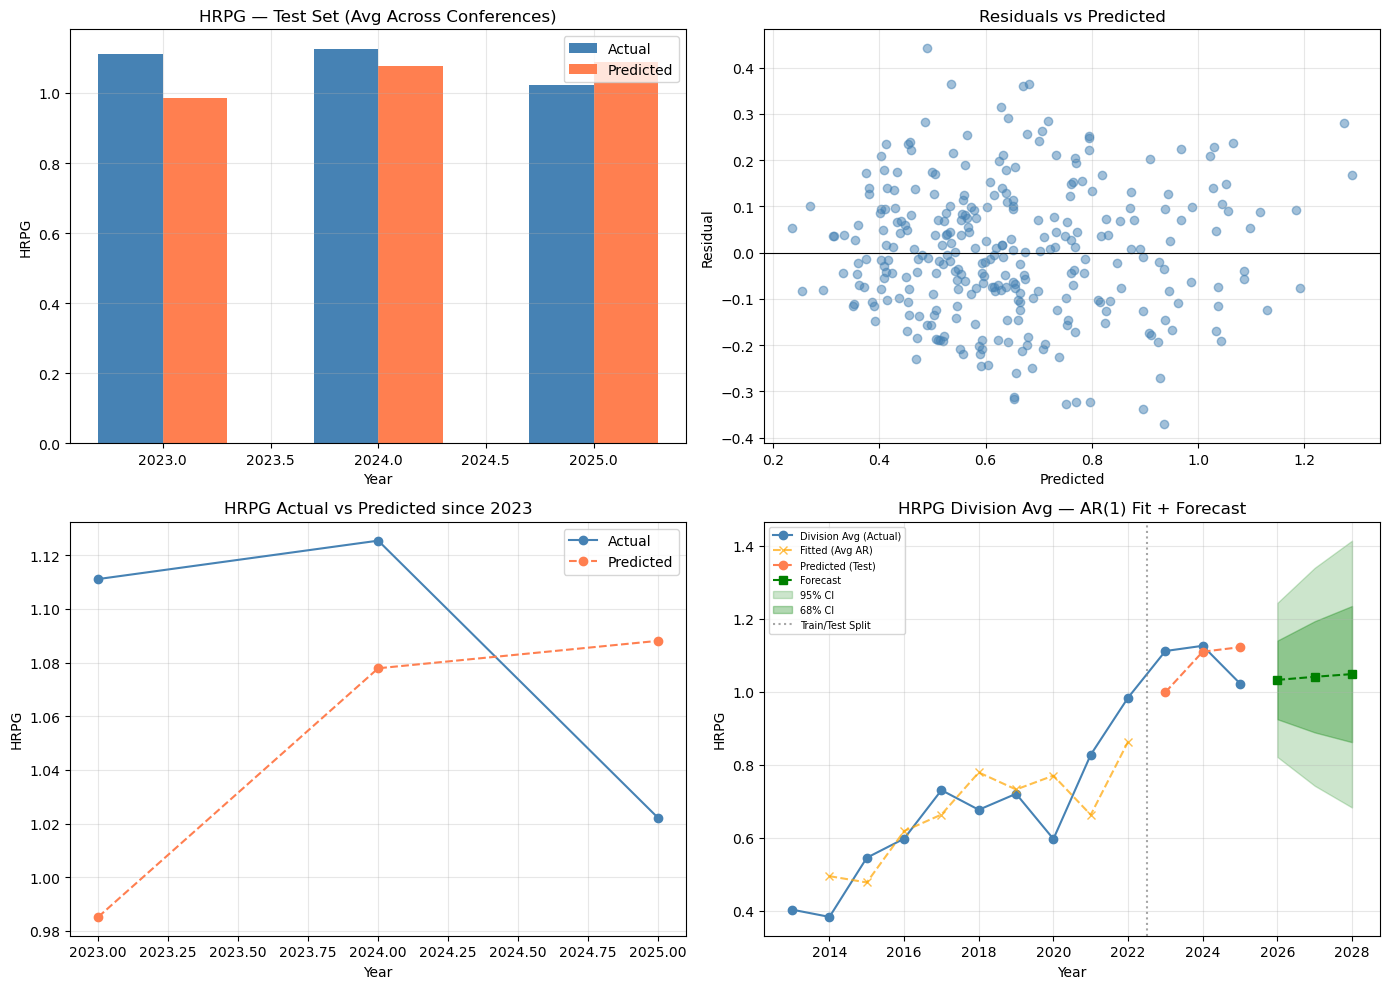

In [194]:
panel, coeffs, avg_coeffs, results = panel_ar(conference_df, 'HRPG', lag=1, test_years=3, forecast_years=3, visualizations=True)

In [ ]:
#years, avg
get_acf_pacf(metric='WHIP', title_name='Division 1', metric_df=OBP_avg_df)